In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/vag_dataset.csv")
df.head()


,knee_condition,severity_level,treatment_advised,rms_amplitude,peak_frequency,spectral_entropy,zero_crossing_rate,mean_frequency
0,normal,NaN,No Treatment,1.051421,20.0,-1799.219746,0.001,39.864485
1,normal,NaN,No Treatment,1.071817,20.0,-2010.827330,0.000,40.652874
2,osteoarthritis,Mild,Physiotherapy,1.098748,20.0,-2172.177329,0.000,39.961072
3,osteoarthritis,Severe,Surgery,1.063046,20.0,-1915.991388,0.000,39.860160
4,ligament_injury,Severe,Surgery,1.222318,20.0,-3331.987202,0.001,44.747680


**Step 1: Basic Data Inspection**

In [ ]:
import numpy as np

# Create an array with the numerical labels you want to check
numerical_labels = np.array([0, 1, 2])

# Inverse transform to get the original categorical names
original_conditions = le.inverse_transform(numerical_labels)

# Print the mapping
print("Mapping of numerical labels to knee conditions:")
for num, condition in zip(numerical_labels, original_conditions):
    print(f"{num}: {condition}")

NameError: name 'le' is not defined

In [ ]:
import numpy as np

# Define the categorical labels you want to check
categorical_labels = ['ligament_injury', 'osteoarthritis', 'normal']

# Transform to get the numerical labels using le_condition (the correct LabelEncoder)
numerical_mapping = le_condition.transform(categorical_labels)

# Print the mapping
print("Mapping of knee conditions to numerical labels:")
for condition, num in zip(categorical_labels, numerical_mapping):
    print(f"{condition}: {num}")

Mapping of knee conditions to numerical labels:
ligament_injury: 0
osteoarthritis: 2
normal: 1


In [ ]:
df['severity_level'] = df['severity_level'].fillna('None')


In [ ]:
df.info()
df.isnull().sum()
df['knee_condition'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   knee_condition      2500 non-null   object 
 1   severity_level      2500 non-null   object 
 2   treatment_advised   2500 non-null   object 
 3   rms_amplitude       2500 non-null   float64
 4   peak_frequency      2500 non-null   float64
 5   spectral_entropy    2500 non-null   float64
 6   zero_crossing_rate  2500 non-null   float64
 7   mean_frequency      2500 non-null   float64
dtypes: float64(5), object(3)
memory usage: 156.4+ KB


,count
knee_condition,
ligament_injury,871
osteoarthritis,834
normal,795


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_condition = LabelEncoder()
le_treatment = LabelEncoder()
le_severity = LabelEncoder()

df['knee_condition'] = le_condition.fit_transform(df['knee_condition'])
df['treatment_advised'] = le_treatment.fit_transform(df['treatment_advised'])
df['severity_level'] = le_severity.fit_transform(df['severity_level'])


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['knee_condition'] = le.fit_transform(df['knee_condition'])
df['severity_level'] = le.fit_transform(df['severity_level'])
df['treatment_advised'] = le.fit_transform(df['treatment_advised'])


In [ ]:
X = df[
    [
        'rms_amplitude',
        'peak_frequency',
        'spectral_entropy',
        'zero_crossing_rate',
        'mean_frequency'
    ]
]


In [ ]:
y = df['knee_condition']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.868
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       174
           1       0.78      0.82      0.80       159
           2       0.82      0.77      0.80       167

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500



# SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report for SVM:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.884

Classification Report for SVM:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       174
           1       0.80      0.85      0.82       159
           2       0.85      0.80      0.82       167

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  # normal / OA / ligament injury
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=1
)


Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5781 - loss: 0.8592 - val_accuracy: 0.6425 - val_loss: 0.6276
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6800 - loss: 0.5615 - val_accuracy: 0.6750 - val_loss: 0.4929
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7356 - loss: 0.4719 - val_accuracy: 0.7225 - val_loss: 0.4499
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7381 - loss: 0.4510 - val_accuracy: 0.7900 - val_loss: 0.4203
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7669 - loss: 0.4285 - val_accuracy: 0.7850 - val_loss: 0.4114
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.3987 - val_accuracy: 0.7850 - val_loss: 0.3927
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8131 - loss: 0.3884 - val_accuracy: 0.8050 - val_loss: 0.3672
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8244 - loss: 0.3636 - val_accuracy: 0.8325 - val_loss:

In [ ]:
from sklearn.metrics import classification_report

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Deep Learning Test Accuracy:", test_acc)

y_pred_dl = model.predict(X_test).argmax(axis=1)
print("\nClassification Report for Deep Learning Model:\n", classification_report(y_test, y_pred_dl))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8840 - loss: 0.2559 
Deep Learning Test Accuracy: 0.8840000033378601
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Classification Report for Deep Learning Model:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       174
           1       0.81      0.83      0.82       159
           2       0.83      0.81      0.82       167

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


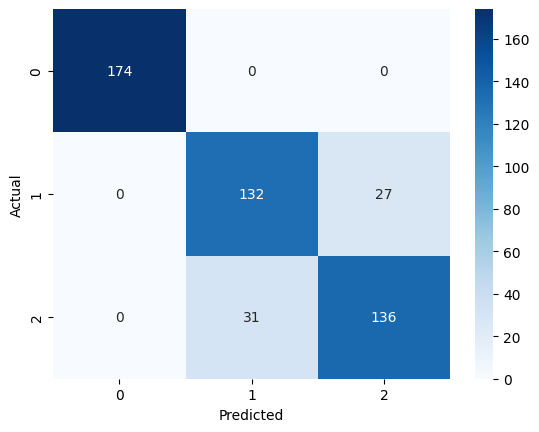

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred_dl = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred_dl)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


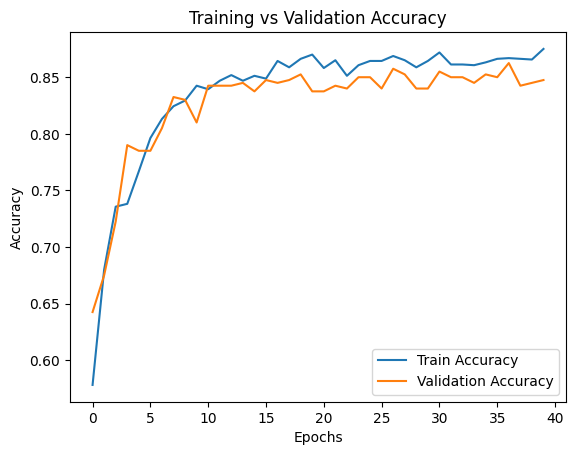

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()


In [ ]:
import pickle

# Define the filename for the pickled model
pickle_filename = 'vag_knee_model.pkl'

try:
    with open(pickle_filename, 'wb') as file:
        pickle.dump(model, file)
    print(f"Model successfully saved as '{pickle_filename}' using pickle.")
except Exception as e:
    print(f"Error saving model with pickle: {e}")
    print("It's generally recommended to use model.save() for Keras models.")

Model successfully saved as 'vag_knee_model.pkl' using pickle.


In [ ]:
model.save("vag_knee_health_model.h5")

In [ ]:
model.save("vag_knee_health_model.keras")


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instantiate Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.886

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       174
           1       0.80      0.86      0.83       159
           2       0.86      0.79      0.82       167

    accuracy                           0.89       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.89      0.89      0.89       500



---

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate KNeighborsClassifier model
knn = KNeighborsClassifier(n_neighbors=5) # Starting with n_neighbors=5 as a default

# Train the model
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Evaluate the model
print("K-Nearest Neighbors Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

K-Nearest Neighbors Accuracy: 0.874

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       174
           1       0.79      0.82      0.80       159
           2       0.82      0.80      0.81       167

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500

